# Active -NN split

In [2]:
import pandas as pd
import numpy as np
from rdkit import Chem
from rdkit.Chem import rdFingerprintGenerator
from rdkit import DataStructs

csv_path = "Bace.csv" 
smiles_col = "SMILES"
label_col = "Label"

df = pd.read_csv(csv_path)
df[smiles_col] = df[smiles_col].astype(str)

mols = []
valid_idx = []

for i, smi in enumerate(df[smiles_col]):
    mol = Chem.MolFromSmiles(smi)
    if mol is not None:
        mols.append(mol)
        valid_idx.append(i)

valid_idx = np.array(valid_idx)
df_valid = df.iloc[valid_idx].copy().reset_index(drop=True)

print(f"Original rows: {len(df):,}")
print(f"Valid molecules: {len(df_valid):,}")
print(f"Invalid molecules: {len(df) - len(df_valid):,}")

Original rows: 1,513
Valid molecules: 1,513
Invalid molecules: 0


In [3]:
# ---- Morgan / ECFP4 fingerprints ----
radius = 2
n_bits = 2048

morgan_gen = rdFingerprintGenerator.GetMorganGenerator(
    radius=radius,
    fpSize=n_bits
)

fps = [morgan_gen.GetFingerprint(mol) for mol in mols]

print(f"Generated {len(fps):,} fingerprints")
print(type(fps[0]))

Generated 1,513 fingerprints
<class 'rdkit.DataStructs.cDataStructs.ExplicitBitVect'>


In [4]:
X = np.zeros((len(fps), n_bits), dtype=np.uint8)

for i, fp in enumerate(fps):
    DataStructs.ConvertToNumpyArray(fp, X[i])

y = df_valid[label_col].astype(int).to_numpy()

print(X.shape)
print(y.shape)

(1513, 2048)
(1513,)


In [5]:
from rdkit import DataStructs
import numpy as np
import pandas as pd

# Assumes you already have:
# df_valid
# fps
# y = df_valid["Label"].astype(int).to_numpy()

active_label = 1
decoy_label = 0

active_idx = np.where(y == active_label)[0]
decoy_idx  = np.where(y == decoy_label)[0]

active_fps = [fps[i] for i in active_idx]
decoy_fps  = [fps[i] for i in decoy_idx]

print(f"Actives: {len(active_idx):,}")
print(f"Decoys:  {len(decoy_idx):,}")

Actives: 691
Decoys:  822


In [6]:
nearest_active_rows = []

for local_decoy_i, global_decoy_i in enumerate(decoy_idx):
    sims = DataStructs.BulkTanimotoSimilarity(
        fps[global_decoy_i],
        active_fps
    )
    
    best_local_active_i = int(np.argmax(sims))
    best_global_active_i = int(active_idx[best_local_active_i])
    best_sim = float(sims[best_local_active_i])
    
    nearest_active_rows.append({
        "decoy_row": global_decoy_i,
        "active_row": best_global_active_i,
        "nn_tanimoto": best_sim,
    })

nn_df = pd.DataFrame(nearest_active_rows)
# Count assigned decoys per active
counts = nn_df.groupby("active_row").size()

# Reindex to include ALL actives (important)
counts = counts.reindex(active_idx, fill_value=0)

# Convert to DataFrame for convenience
active_distribution = pd.DataFrame({
    "active_row": counts.index,
    "n_assigned_decoys": counts.values
})

print(active_distribution.shape)  
active_distribution.head()

(691, 2)


,active_row,n_assigned_decoys
0,0,0
1,1,0
2,2,1
3,3,0
4,4,0


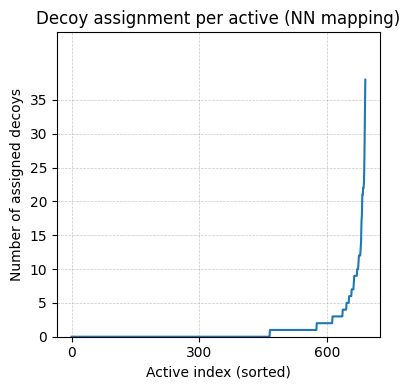

In [7]:
import matplotlib.pyplot as plt
import numpy as np

# Sort
active_distribution_sorted = active_distribution.sort_values(
    "n_assigned_decoys"
).reset_index(drop=True)

x = active_distribution_sorted.index
y = active_distribution_sorted["n_assigned_decoys"]

plt.figure(figsize=(4, 4))
plt.plot(x, y)

plt.xticks(np.arange(0, len(x)+1, 300))  
plt.yticks(np.arange(0, y.max()+1, 5))   
plt.ylim(0,45)
# ---- grid ----
plt.grid(True, which="both", linestyle="--", linewidth=0.5, alpha=0.7)

# labels
plt.xlabel("Active index (sorted)")
plt.ylabel("Number of assigned decoys")
plt.title("Decoy assignment per active (NN mapping)")

plt.tight_layout()
plt.savefig("nn_decoys_actives_bace.png", dpi=800)
plt.show()

In [8]:
import numpy as np
import pandas as pd

TRAIN_FRAC = 0.80
VAL_FRAC   = 0.10
TEST_FRAC  = 0.10

seed = 42
rng = np.random.default_rng(seed)

n_total = len(df_valid)
target_sizes = {
    "train": TRAIN_FRAC * n_total,
    "val":   VAL_FRAC * n_total,
    "test":  TEST_FRAC * n_total,
}

target_pos = {
    "train": TRAIN_FRAC * np.sum(y == 1),
    "val":   VAL_FRAC * np.sum(y == 1),
    "test":  TEST_FRAC * np.sum(y == 1),
}

target_neg = {
    "train": TRAIN_FRAC * np.sum(y == 0),
    "val":   VAL_FRAC * np.sum(y == 0),
    "test":  TEST_FRAC * np.sum(y == 0),
}
label_col = "Label" 

y = df_valid[label_col].astype(int).to_numpy()

active_idx = np.where(y == 1)[0]
decoy_idx  = np.where(y == 0)[0]

print("df_valid:", len(df_valid))
print("y:", len(y))
print("actives:", len(active_idx))
print("decoys:", len(decoy_idx))
print("max active idx:", active_idx.max())
print("max decoy idx:", decoy_idx.max())

df_valid: 1513
y: 1513
actives: 691
decoys: 822
max active idx: 793
max decoy idx: 1512


targets train: 4057
val:    507
test:   507

In [9]:
from rdkit import DataStructs
import numpy as np
import pandas as pd

active_fps = [fps[i] for i in active_idx]

nearest_active_rows = []

for decoy_i in decoy_idx:
    sims = DataStructs.BulkTanimotoSimilarity(
        fps[decoy_i],
        active_fps
    )

    best_local_active_i = int(np.argmax(sims))
    best_active_i = int(active_idx[best_local_active_i])

    nearest_active_rows.append({
        "decoy_row": int(decoy_i),
        "active_row": best_active_i,
        "nn_tanimoto": float(sims[best_local_active_i]),
    })

nn_df = pd.DataFrame(nearest_active_rows)

print(nn_df.shape)
print(nn_df[["decoy_row", "active_row"]].max())

(822, 3)
decoy_row     1512
active_row     792
dtype: int64


In [10]:
groups = []

for active in active_idx:
    decoys_for_active = nn_df.loc[
        nn_df["active_row"] == active,
        "decoy_row"
    ].to_numpy(dtype=int)

    group_indices = np.unique(
        np.concatenate([[active], decoys_for_active])
    ).astype(int)

    group_y = y[group_indices]

    groups.append({
        "active_row": int(active),
        "indices": group_indices,
        "n_total": int(len(group_indices)),
        "n_pos": int(np.sum(group_y == 1)),
        "n_neg": int(np.sum(group_y == 0)),
    })

groups_df = pd.DataFrame([
    {
        "active_row": g["active_row"],
        "n_total": g["n_total"],
        "n_pos": g["n_pos"],
        "n_neg": g["n_neg"],
    }
    for g in groups
])

groups_df.sort_values("n_total", ascending=False).head(10)

,active_row,n_total,n_pos,n_neg
129,232,39,1,38
243,346,34,1,33
539,642,28,1,27
100,100,24,1,23
58,58,23,1,22
99,99,23,1,22
72,72,22,1,21
27,27,22,1,21
83,83,19,1,18
684,787,18,1,17


In [11]:
# Shuffle first, then sort by group size descending
order = np.arange(len(groups))
rng.shuffle(order)

order = sorted(
    order,
    key=lambda i: groups[i]["n_total"],
    reverse=True
)

running = {
    "train": {"indices": [], "n_total": 0, "n_pos": 0, "n_neg": 0},
    "val":   {"indices": [], "n_total": 0, "n_pos": 0, "n_neg": 0},
    "test":  {"indices": [], "n_total": 0, "n_pos": 0, "n_neg": 0},
}

def split_score(split_name, group):
    new_total = running[split_name]["n_total"] + group["n_total"]
    new_pos   = running[split_name]["n_pos"]   + group["n_pos"]
    new_neg   = running[split_name]["n_neg"]   + group["n_neg"]

    size_error = ((new_total - target_sizes[split_name]) ** 2) / max(1, target_sizes[split_name])
    pos_error  = ((new_pos   - target_pos[split_name])   ** 2) / max(1, target_pos[split_name])
    neg_error  = ((new_neg   - target_neg[split_name])   ** 2) / max(1, target_neg[split_name])

    overfill_penalty = 0
    if split_name in ["val", "test"] and new_total > target_sizes[split_name]:
        overfill_penalty = 10 * ((new_total - target_sizes[split_name]) ** 2) / target_sizes[split_name]

    return size_error + pos_error + neg_error + overfill_penalty

for group_i in order:
    group = groups[group_i]

    scores = {
        split: split_score(split, group)
        for split in ["train", "val", "test"]
    }

    best_split = min(scores, key=scores.get)

    running[best_split]["indices"].extend(group["indices"].tolist())
    running[best_split]["n_total"] += group["n_total"]
    running[best_split]["n_pos"]   += group["n_pos"]
    running[best_split]["n_neg"]   += group["n_neg"]

In [12]:
assignment = np.full(len(df_valid), "unassigned", dtype=object)

for split in ["train", "val", "test"]:
    idx = np.array(running[split]["indices"], dtype=int)
    assignment[idx] = split

print(pd.Series(assignment).value_counts())

train    914
val      300
test     299
Name: count, dtype: int64


In [13]:
summary = []

for split in ["train", "val", "test"]:
    idx = np.where(assignment == split)[0]

    summary.append({
        "split": split,
        "n_total": len(idx),
        "fraction": len(idx) / len(df_valid),
        "n_actives": int(np.sum(y[idx] == 1)),
        "n_decoys": int(np.sum(y[idx] == 0)),
        "active_fraction": np.mean(y[idx] == 1),
    })

split_summary = pd.DataFrame(summary)
split_summary

,split,n_total,fraction,n_actives,n_decoys,active_fraction
0,train,914,0.604098,562,352,0.614880
1,val,300,0.198282,64,236,0.213333
2,test,299,0.197621,65,234,0.217391


In [14]:
df_split = df_valid.copy()
df_split["split"] = assignment

df_split.to_csv("bace_nn.csv", index=False)

# Scaffold split

In [15]:
from rdkit import Chem
from rdkit.Chem.Scaffolds import MurckoScaffold

def get_scaffold(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None
    return MurckoScaffold.MurckoScaffoldSmiles(mol=mol)

df_valid["scaffold"] = df_valid["SMILES"].apply(get_scaffold)

print(df_valid["scaffold"].nunique(), "unique scaffolds")

671 unique scaffolds


In [16]:
groups = []

for scaffold, group_df in df_valid.groupby("scaffold"):
    indices = group_df.index.to_numpy(dtype=int)
    group_y = y[indices]

    groups.append({
        "scaffold": scaffold,
        "indices": indices,
        "n_total": len(indices),
        "n_pos": int(np.sum(group_y == 1)),
        "n_neg": int(np.sum(group_y == 0)),
    })

# sort largest first (important)
groups = sorted(groups, key=lambda g: g["n_total"], reverse=True)

print("Top scaffold sizes:")
print([g["n_total"] for g in groups[:10]])

Top scaffold sizes:
[55, 53, 41, 31, 26, 26, 22, 19, 17, 16]


In [17]:
n_total = len(df_valid)

target_sizes = {
    "train": 0.80 * n_total,
    "val":   0.10 * n_total,
    "test":  0.10 * n_total,
}

target_pos = {
    "train": 0.80 * np.sum(y == 1),
    "val":   0.10 * np.sum(y == 1),
    "test":  0.10 * np.sum(y == 1),
}

target_neg = {
    "train": 0.80 * np.sum(y == 0),
    "val":   0.10 * np.sum(y == 0),
    "test":  0.10 * np.sum(y == 0),
}

In [18]:
running = {
    "train": {"indices": [], "n_total": 0, "n_pos": 0, "n_neg": 0},
    "val":   {"indices": [], "n_total": 0, "n_pos": 0, "n_neg": 0},
    "test":  {"indices": [], "n_total": 0, "n_pos": 0, "n_neg": 0},
}

def split_score(split, group):
    new_total = running[split]["n_total"] + group["n_total"]
    new_pos   = running[split]["n_pos"] + group["n_pos"]
    new_neg   = running[split]["n_neg"] + group["n_neg"]

    size_error = ((new_total - target_sizes[split]) ** 2) / max(1, target_sizes[split])
    pos_error  = ((new_pos   - target_pos[split]) ** 2) / max(1, target_pos[split])
    neg_error  = ((new_neg   - target_neg[split]) ** 2) / max(1, target_neg[split])

    # discourage overfilling val/test
    penalty = 0
    if split in ["val", "test"] and new_total > target_sizes[split]:
        penalty = 5 * ((new_total - target_sizes[split]) ** 3) / target_sizes[split]

    return size_error + pos_error + neg_error + penalty
for group in groups:
    scores = {
        split: split_score(split, group)
        for split in ["train", "val", "test"]
    }

    best_split = min(scores, key=scores.get)

    running[best_split]["indices"].extend(group["indices"].tolist())
    running[best_split]["n_total"] += group["n_total"]
    running[best_split]["n_pos"]   += group["n_pos"]
    running[best_split]["n_neg"]   += group["n_neg"]

In [19]:
assignment = np.empty(len(df_valid), dtype=object)

for split in ["train", "val", "test"]:
    idx = np.array(running[split]["indices"], dtype=int)
    assignment[idx] = split

df_valid["split"] = assignment

In [20]:
summary = []

for split in ["train", "val", "test"]:
    idx = np.where(assignment == split)[0]

    summary.append({
        "split": split,
        "n_total": len(idx),
        "fraction": len(idx) / len(df_valid),
        "n_actives": int(np.sum(y[idx] == 1)),
        "n_decoys": int(np.sum(y[idx] == 0)),
        "active_fraction": np.mean(y[idx] == 1),
    })

pd.DataFrame(summary)

,split,n_total,fraction,n_actives,n_decoys,active_fraction
0,train,1136,0.750826,480,656,0.422535
1,val,192,0.126900,82,110,0.427083
2,test,185,0.122274,129,56,0.697297


In [21]:
df_valid.to_csv("bace_scaffold_split.csv", index=False)

# Measuring ambiguous stereochemistry

In [23]:

from rdkit import Chem
import pandas as pd

def has_undefined_chiral(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return False

    Chem.AssignStereochemistry(mol, force=True, cleanIt=True)

    chiral_centers = Chem.FindMolChiralCenters(
        mol,
        includeUnassigned=True
    )

    return any(label == "?" for _, label in chiral_centers)


df_valid["undefined_chiral"] = df_valid["SMILES"].apply(has_undefined_chiral)

print(df_valid["undefined_chiral"].sum())
print(f"{df_valid['undefined_chiral'].mean():.2%}")

1070
70.72%
